In [32]:
import pandas as pd
import io
from PIL import Image
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools, AllChem

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import SimilarityMaps



## Training XGBoost on Molecular Fingerprints

We train an XGBoost classifier using molecular fingerprint vectors (e.g., Morgan fingerprints) as input features. These fingerprints encode chemical structure information in a fixed-length binary format. The trained model will not only predict molecular activity, but its structure enables downstream interpretability analyses—allowing us to probe which molecular substructures most influence predictions.

In [2]:
data = pd.read_csv("data/HIV.csv")
data = data.dropna(subset=['smiles'])

data['molecule'] = [Chem.MolFromSmiles(smiles) for smiles in data['smiles']]
data = data.dropna(subset=['molecule'])

[06:59:54] Explicit valence for atom # 3 Al, 6, is greater than permitted
[06:59:54] Explicit valence for atom # 5 B, 5, is greater than permitted
[06:59:56] Explicit valence for atom # 16 Al, 9, is greater than permitted
[06:59:57] Explicit valence for atom # 4 Al, 9, is greater than permitted
[06:59:59] Explicit valence for atom # 12 Al, 7, is greater than permitted
[06:59:59] Explicit valence for atom # 13 Al, 7, is greater than permitted
[07:00:00] WARNING: not removing hydrogen atom without neighbors
[07:00:00] WARNING: not removing hydrogen atom without neighbors
[07:00:00] Explicit valence for atom # 6 Ge, 5, is greater than permitted


In [3]:
data

,smiles,activity,HIV_active,molecule
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0,<rdkit.Chem.rdchem.Mol object at 0x1238386d0>
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123838740>
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0,<rdkit.Chem.rdchem.Mol object at 0x1238387b0>
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123838820>
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123838890>
...,...,...,...,...
41122,CCC1CCC2c3c([nH]c4ccc(C)cc34)C3C(=O)N(N(C)C)C(...,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123ccaab0>
41123,Cc1ccc2[nH]c3c(c2c1)C1CCC(C(C)(C)C)CC1C1C(=O)N...,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123ccab20>
41124,Cc1ccc(N2C(=O)C3c4[nH]c5ccccc5c4C4CCC(C(C)(C)C...,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123ccab90>
41125,Cc1cccc(N2C(=O)C3c4[nH]c5ccccc5c4C4CCC(C(C)(C)...,CI,0,<rdkit.Chem.rdchem.Mol object at 0x123ccac00>


In [ ]:
data['fingerprint_512'] = [AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=512) for mol in tqdm(data['molecule'])]
data['fingerprint_1024'] = [AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024) for mol in tqdm(data['molecule'])]
data['fingerprint_2048'] = [AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048) for mol in tqdm(data['molecule'])]

In [7]:
X_512 = np.asarray(list(data.fingerprint_512.values))
print(X_512.shape)

(41120, 512)


In [ ]:
X_1024 = np.asarray(list(data.fingerprint_1024.values))
print(X_1024.shape)

(41120, 1024)


In [42]:
X_2048 = np.asarray(list(data.fingerprint_2048.values))
print(X_2048.shape)

(41120, 2048)


In [43]:
# measure the sparsity of the fingerprint matrix per feature
sparsity_2048 = 1.0 - (np.count_nonzero(X_2048, axis=0) / X_2048.shape[0])
sparsity_512 = 1.0 - (np.count_nonzero(X_512, axis=0) / X_512.shape[0])
sparsity_1024 = 1.0 - (np.count_nonzero(X_1024, axis=0) / X_1024.shape[0])

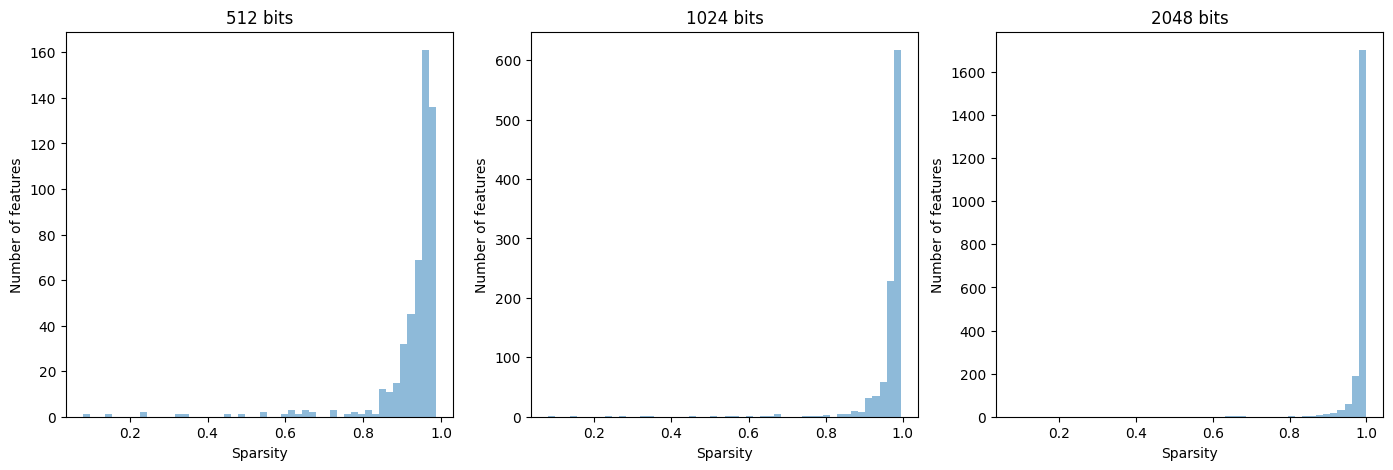

In [44]:
# make a plot comparing the three sparsity distributions
fig, ax = plt.subplots(1, 3, figsize=(17,5))
ax[2].hist(sparsity_2048, bins=50, alpha=0.5, label='2048 bits')
ax[1].hist(sparsity_1024, bins=50, alpha=0.5, label='1024 bits')
ax[0].hist(sparsity_512, bins=50, alpha=0.5, label='512 bits')
# set titles and labels
ax[0].set_title('512 bits')
ax[0].set_xlabel('Sparsity')
ax[0].set_ylabel('Number of features')
ax[1].set_title('1024 bits')
ax[1].set_xlabel('Sparsity')
ax[1].set_ylabel('Number of features')
ax[2].set_title('2048 bits')
ax[2].set_xlabel('Sparsity')
ax[2].set_ylabel('Number of features')

plt.show()

# Train a XGB model

In [ ]:
from xgboost import XGBClassifier
from scripts.train import train_eval_model
from scripts.plot import plot_single_model_results
from sklearn.model_selection import train_test_split

In [46]:
Y = data['HIV_active'].values
activity = data['activity'].values

Model with 512 bit fingerprints


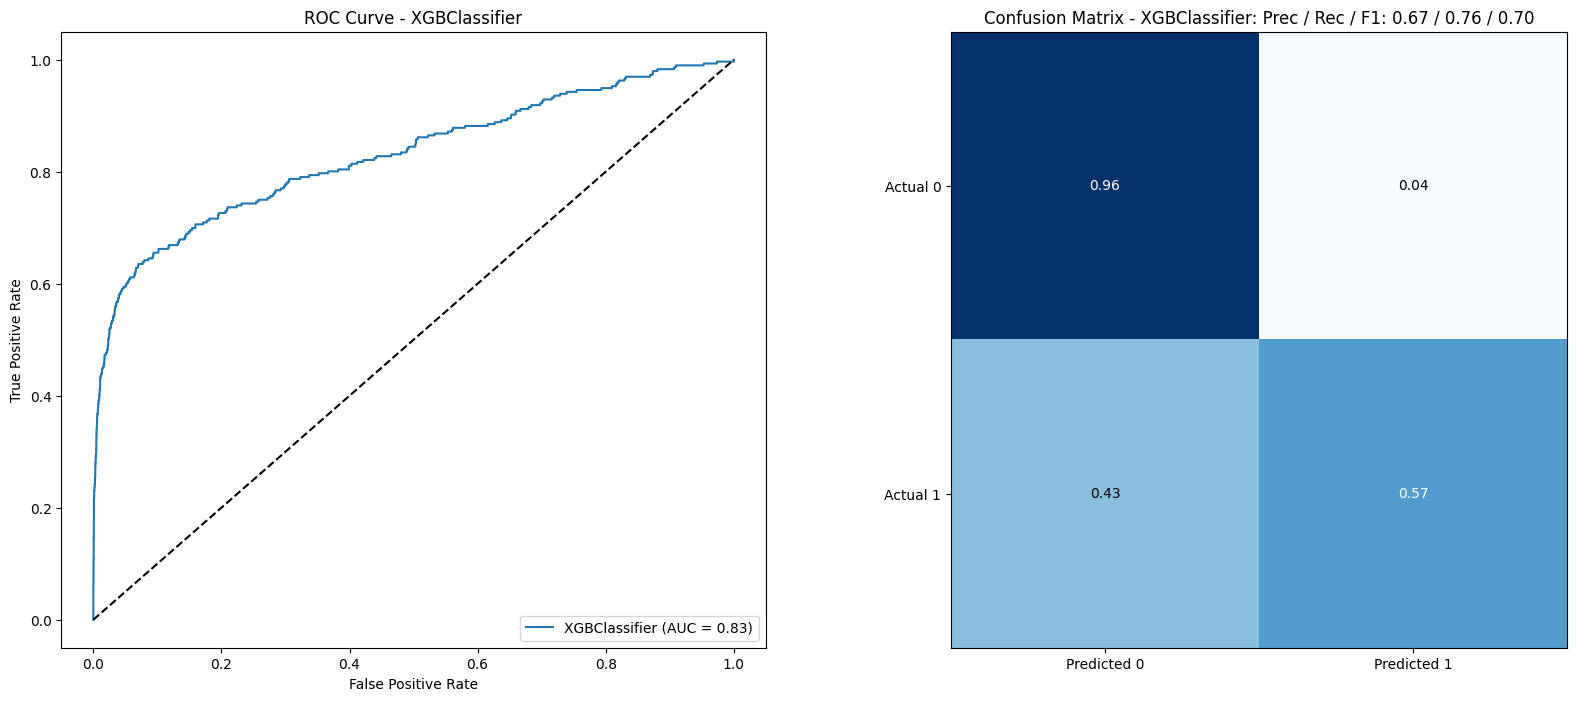

In [47]:
model = XGBClassifier()

X_train, X_test, y_train, y_test = train_test_split(X_512, Y, test_size=0.2, random_state=42)
fitted_model_512, tpr, fpr, optimal_threshold, performance_dict, importances = train_eval_model(model, X_train, y_train, X_test, y_test, 
                                                                                    feature_selection=False, feature_importance=False)

print('Model with 512 bit fingerprints')
fig, axes = plt.subplots(1, 2, figsize=(20, 8 ))
plot = plot_single_model_results(1, axes, model.__class__.__name__, tpr, fpr, performance_dict, importances)

Model with 1024 bit fingerprints


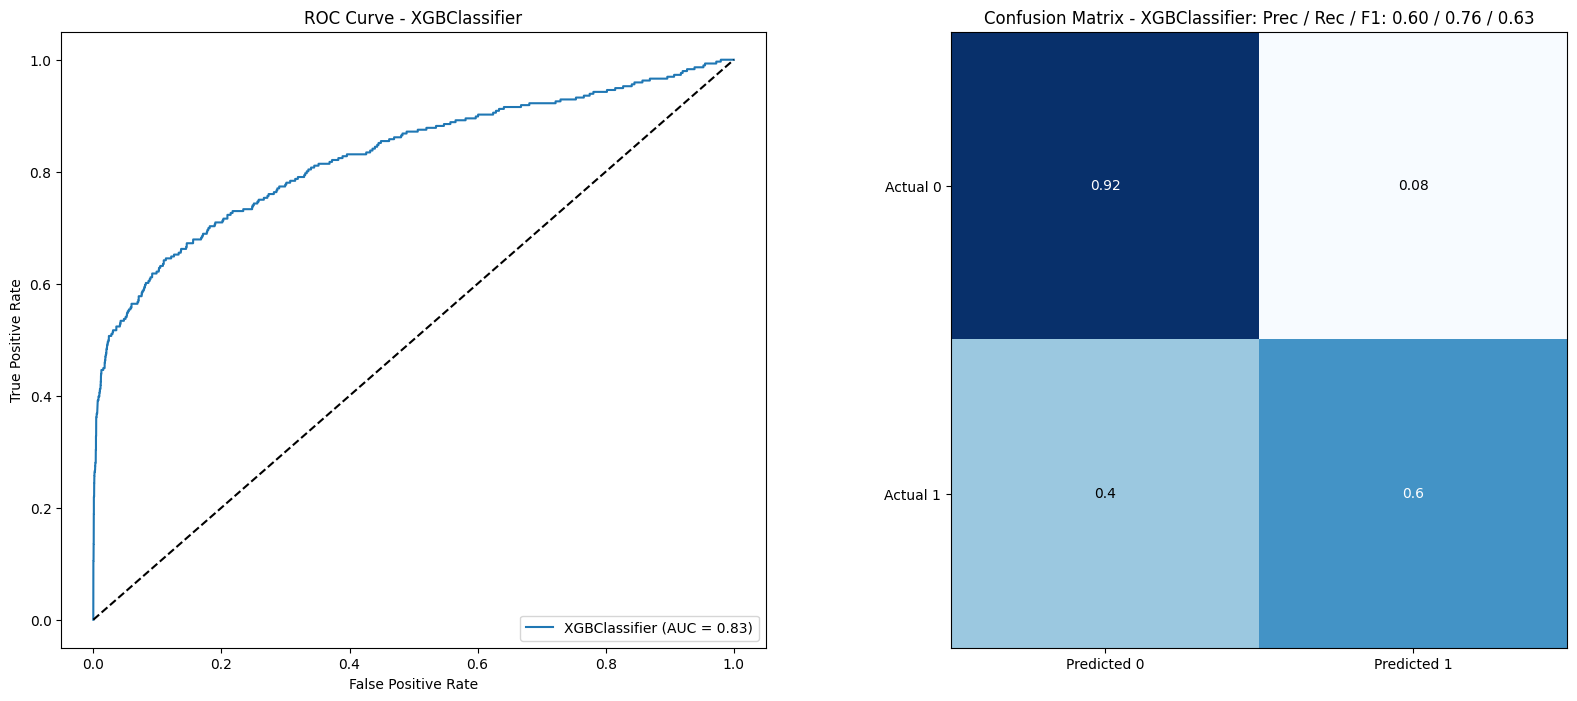

In [48]:
model = XGBClassifier()

X_train, X_test, y_train, y_test = train_test_split(X_1024, Y, test_size=0.2, random_state=42)
fitted_model_1024, tpr, fpr, optimal_threshold, performance_dict, importances = train_eval_model(model, X_train, y_train, X_test, y_test, 
                                                                                    feature_selection=False, feature_importance=False)

print('Model with 1024 bit fingerprints')
fig, axes = plt.subplots(1, 2, figsize=(20, 8 ))
plot = plot_single_model_results(1, axes, model.__class__.__name__, tpr, fpr, performance_dict, importances)

Model with 2048 bit fingerprints


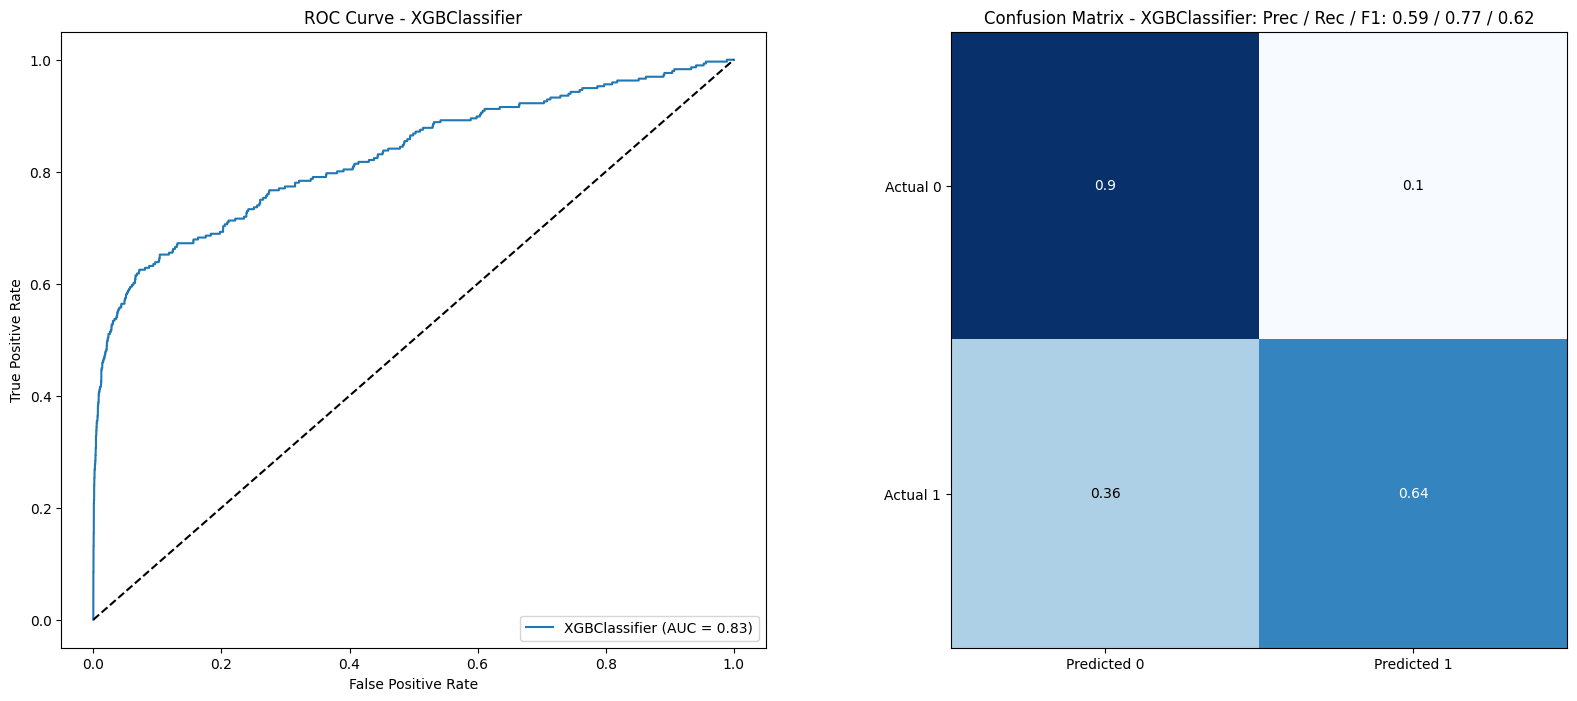

In [49]:
model = XGBClassifier()

X_train, X_test, y_train, y_test = train_test_split(X_2048, Y, test_size=0.2, random_state=42)
fitted_model_2048, tpr, fpr, optimal_threshold, performance_dict, importances = train_eval_model(model, X_train, y_train, X_test, y_test, 
                                                                                    feature_selection=False, feature_importance=False)

print('Model with 2048 bit fingerprints')
fig, axes = plt.subplots(1, 2, figsize=(20, 8 ))
plot = plot_single_model_results(1, axes, model.__class__.__name__, tpr, fpr, performance_dict, importances)

Text(0, 0.5, 'Density')

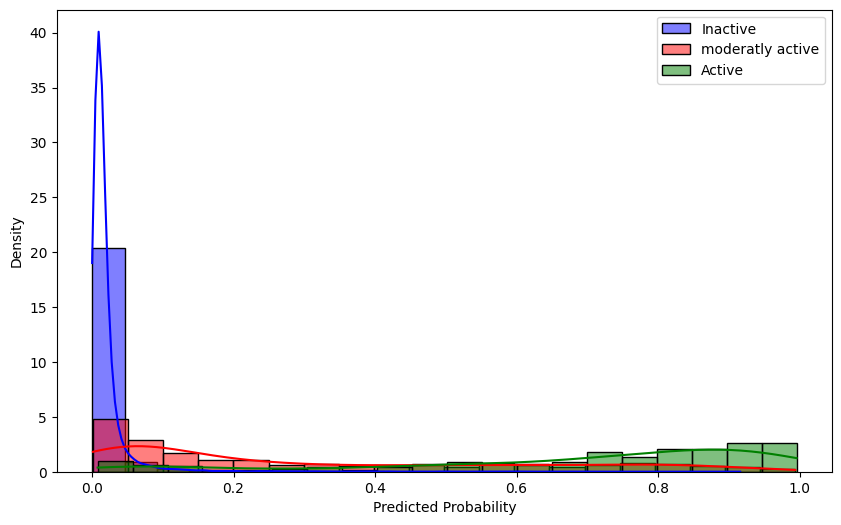

In [50]:
# predict the logits and plot the logit distribution for each class of activity

y_test_prob = fitted_model_2048.predict_proba(X_2048)[:,1]

plt.figure(figsize=(10,6))
# normalize the histograms to form a density
sns.histplot((y_test_prob[activity == 'CI']), color='blue', label='Inactive', kde=True, stat="density", bins=20)
sns.histplot(y_test_prob[activity == 'CM'], color='red', label='moderatly active', kde=True, stat="density", bins=20)
sns.histplot(y_test_prob[activity == 'CA'], color='green', label='Active', kde=True, stat="density", bins=20)
plt.legend()
plt.xlabel('Predicted Probability')
plt.ylabel('Density')

In [21]:
data['activity'].value_counts()

activity
CI    39677
CM     1039
CA      404
Name: count, dtype: int64

# Interpretability overview (excluding model training)

The method estimates how much each atom (and connected groups of atoms) contributes to a model prediction by perturbing the Morgan fingerprint representation in an atom-local way, measuring the change in predicted probability, and aggregating connected atoms with similar contributions. Inspired by Pat Walters' discussion of Morgan-fingerprint interpretability: https://patwalters.github.io/practicalcheminformatics/jupyter/ml/interpretability/2021/06/03/interpretable.html

# Main steps

1. Molecule preparation
    - Read SMILES, convert to RDKit Mol objects, drop invalid molecules.

2. Baseline prediction
    - Compute the full-molecule Morgan fingerprint and obtain the model prediction for the intact molecule (baseline probability).

3. Atom-level perturbation and scoring
    - For each atom, generate a modified fingerprint that reflects the fingerprint with that atom’s local environment changed/removed (via RDKit utilities).
    - Recompute the model prediction using the modified fingerprint.
    - Define the atom contribution (delta) as baseline_pred − atom_pred (positive = atom supports the prediction).

4. Construct atom graph and group by similarity
    - Build the molecular graph (atoms = nodes, bonds = edges).
    - Group connected atoms whose delta values are within a chosen threshold of one another to form chemically meaningful substructures.
    - Summarize each group by a representative score (e.g., mean delta) and, when possible, extract the corresponding submol.

5. Cross-molecule aggregation
    - Convert extracted substructures to canonical SMILES for exact structural matching.
    - Group identical substructures across molecules, and aggregate their contribution statistics (count, mean, spread).
    - Report and visualize recurring motifs that consistently influence predictions.

6. Visualization and inspection
    - Show per-atom heatmaps (similarity maps) on molecules and images of representative substructures.
    - Use basic plots (bar/box/scatter) to inspect distribution and robustness of aggregated motifs.


In [ ]:
from scripts.atom_permutation_interpretability import extract_similar_substructures, get_similarity_map_from_model, visualize_substructures, extract_substructures_with_graph_matching
from collections import defaultdict
import networkx as nx

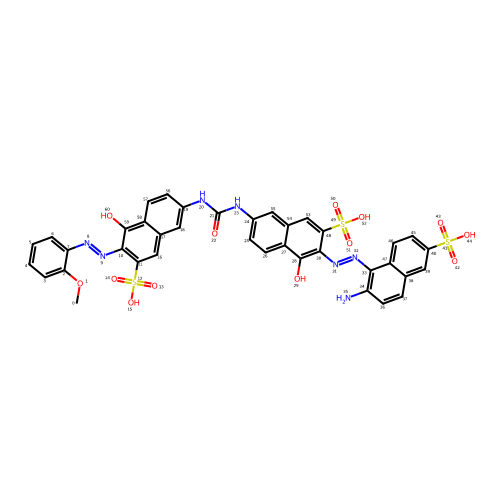

In [51]:
example_mol = Chem.Mol(data[data['HIV_active']==1].molecule.values[50])
d2d = rdMolDraw2D.MolDraw2DSVG(500,500)
d2d.drawOptions().addAtomIndices=True
d2d.DrawMolecule(example_mol)
d2d.FinishDrawing()
SVG(d2d.GetDrawingText())

In [52]:
example_fp = AllChem.GetMorganFingerprintAsBitVect(example_mol,2, nBits=2048)
example_pred = fitted_model_2048.predict_proba(np.array([example_fp]))[0][1]


[07:23:18] DEPRECATION WARNING: please use MorganGenerator


In [53]:
res = []
for atm in example_mol.GetAtoms():
    idx = atm.GetIdx()
    fp = SimilarityMaps.GetMorganFingerprint(example_mol,idx)
    pred_val = model.predict_proba(np.array([fp]))[0][1]
    delta = example_pred - pred_val
    res.append([atm.GetSymbol(),idx,pred_val,delta])
tmp_df = pd.DataFrame(res,columns = ["Atom Type","Atom Index","Predicted Value","Delta"])
tmp_df.sort_values("Delta",ascending=False)

[07:23:21] DEPRECATION WARNING: please use MorganGenerator


,Atom Type,Atom Index,Predicted Value,Delta
48,C,48,0.031223,0.654845
11,C,11,0.031223,0.654845
12,S,12,0.036311,0.649758
49,S,49,0.036311,0.649758
24,C,24,0.037819,0.648250
...,...,...,...,...
8,N,8,0.625370,0.060699
34,C,34,0.667998,0.018071
35,N,35,0.686069,0.000000
6,C,6,0.686069,0.000000


In [54]:
def show_png(data):
    bio = io.BytesIO(data)
    img = Image.open(bio)
    return img

def get_pred(fp, pred_function):
    fp = np.array([list(fp)])
    return float(pred_function(fp)[0][1])

def plot_similarity_map(mol, model):
    d = Draw.MolDraw2DCairo(400, 400)
    SimilarityMaps.GetSimilarityMapForModel(mol,
                                            SimilarityMaps.GetMorganFingerprint,
                                            lambda x : get_pred(x, model.predict_proba),
                                            draw2d=d)
    d.FinishDrawing()
    return d

[07:24:16] DEPRECATION WARNING: please use MorganGenerator


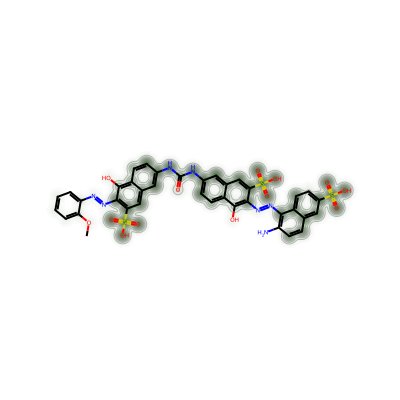

In [55]:
test_row = 1
test_mol = example_mol
res = plot_similarity_map(test_mol,fitted_model_2048)
show_png(res.GetDrawingText())

## Extracting Important Substructures from a Single Molecule

To interpret model predictions at the substructure level, we:

1. **Compute Atom Contributions:**  
    For each atom in the molecule, we locally perturb its fingerprint and measure the change in predicted probability. This quantifies each atom's contribution to the prediction.

2. **Group Atoms by Prediction Difference:**  
    Atoms with similar contribution values and chemical connectivity are grouped into substructures.

3. **Extract and Visualize Substructures:**  
    The resulting atom groups are converted into molecular fragments, which are visualized and ranked by their mean contribution scores.  
    This highlights the most influential regions of the molecule for the model's decision.

[10:37:28] DEPRECATION WARNING: please use MorganGenerator


Top 5 substructures by similarity:
--------------------------------------------------

Substructure 1:
Atom indices: [23, 24, 25, 55]
Mean similarity: 0.6444
Number of atoms: 4


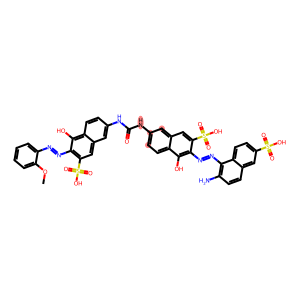


Substructure 2:
Atom indices: [19, 20, 56]
Mean similarity: 0.6442
Number of atoms: 3


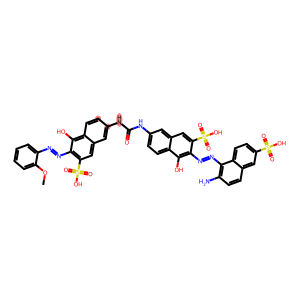


Substructure 3:
Atom indices: [11, 12, 13, 14, 15]
Mean similarity: 0.6357
Number of atoms: 5


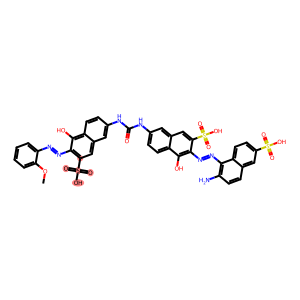


Substructure 4:
Atom indices: [49, 50, 51, 52]
Mean similarity: 0.6310
Number of atoms: 4


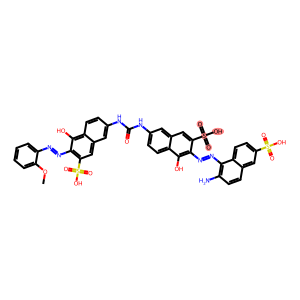


Substructure 5:
Atom indices: [41, 42, 43, 44]
Mean similarity: 0.6290
Number of atoms: 4


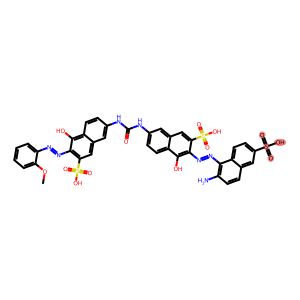


All substructures:
Group 1: Atoms [23, 24, 25, 55], Mean Prediction Difference: 0.6444
Group 2: Atoms [19, 20, 56], Mean Prediction Difference: 0.6442
Group 3: Atoms [11, 12, 13, 14, 15], Mean Prediction Difference: 0.6357
Group 4: Atoms [49, 50, 51, 52], Mean Prediction Difference: 0.6310
Group 5: Atoms [41, 42, 43, 44], Mean Prediction Difference: 0.6290
Group 6: Atoms [53], Mean Prediction Difference: 0.5811
Group 7: Atoms [47], Mean Prediction Difference: 0.5590
Group 8: Atoms [30], Mean Prediction Difference: 0.5384
Group 9: Atoms [39], Mean Prediction Difference: 0.5089
Group 10: Atoms [37], Mean Prediction Difference: 0.4902
Group 11: Atoms [17], Mean Prediction Difference: 0.3877
Group 12: Atoms [27], Mean Prediction Difference: 0.3157
Group 13: Atoms [59], Mean Prediction Difference: 0.2008
Group 14: Atoms [22], Mean Prediction Difference: 0.1519
Group 15: Atoms [45], Mean Prediction Difference: 0.0782
Group 16: Atoms [2, 3, 4, 5, 7, 8, 9], Mean Prediction Difference: 0.0672


In [91]:
# Add this cell after your existing Prediction Difference map code

# Get similarity map for the example molecule
similarity_map = get_similarity_map_from_model(example_mol, fitted_model_2048)

# Extract substructures with similar Prediction Difference values
substructures = extract_similar_substructures(example_mol, similarity_map, threshold=0.05)

# Visualize the results
visualize_substructures(example_mol, substructures, top_n=5)

# Print detailed information
print("\nAll substructures:")
for i, (atom_indices, mean_sim, submol) in enumerate(substructures):
    print(f"Group {i+1}: Atoms {atom_indices}, Mean Prediction Difference: {mean_sim:.4f}")

## Systematic Extraction of Important Substructures Across the Whole Dataset

To move from single-molecule interpretability to a dataset-wide analysis, we apply the atom-level perturbation and grouping method to many molecules and aggregate recurring substructures:

1. **Sample Molecules:**  
    Select a representative subset (or all) molecules from the dataset.

2. **Per-Molecule Analysis:**  
    For each molecule:
    - Compute atom-level contributions using fingerprint perturbation and model prediction.
    - Group atoms with similar contributions into connected substructures.
    - Extract each substructure as a molecular fragment and record its contribution score.

3. **Aggregate Across Molecules:**  
    - Group identical substructures by comparing their molecular graph topology (using graph isomorphism).

4. **Filter and Rank Motifs:**  
    - Identify substructures that occur frequently and consistently influence predictions.
    - Rank motifs by their mean contribution.

5. **Visualization and Reporting:**  
    - Visualize top substructures and their statistics.
    - Use plots (bar, scatter, box) to inspect the distribution and robustness of influential motifs.



In [ ]:
# supress warnings for cleaner output
substructure_groups = extract_substructures_with_graph_matching(data, fitted_model_2048, sample_size=10000)

print(f"Found {len(substructure_groups)} unique substructure groups")


Visualizing top substructures:
Substructure 1:
   Count: 5, Mean Prediction Difference: 0.7351


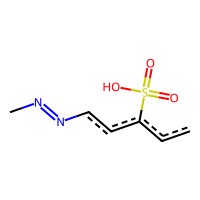

Substructure 2:
   Count: 9, Mean Prediction Difference: 0.5538


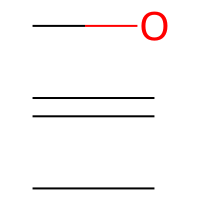

Substructure 3:
   Count: 9, Mean Prediction Difference: 0.5432


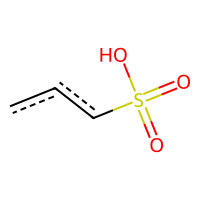

Substructure 4:
   Count: 34, Mean Prediction Difference: 0.5298


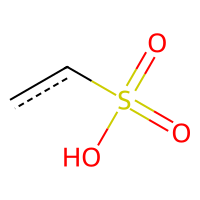

Substructure 5:
   Count: 6, Mean Prediction Difference: 0.5122


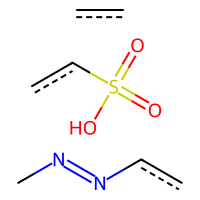

Substructure 6:
   Count: 12, Mean Prediction Difference: 0.4396


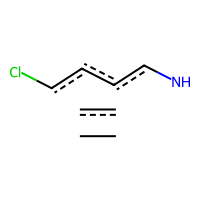

Substructure 7:
   Count: 5, Mean Prediction Difference: 0.3836


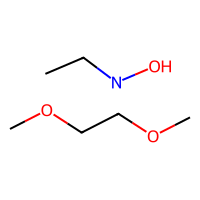

Substructure 8:
   Count: 35, Mean Prediction Difference: 0.3760


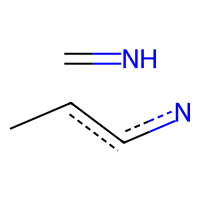

Substructure 9:
   Count: 152, Mean Prediction Difference: 0.3701


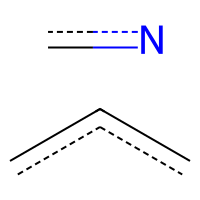

Substructure 10:
   Count: 18, Mean Prediction Difference: 0.3639


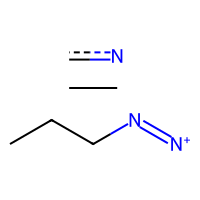

In [89]:
# Analyze the grouped substructures
analysis_results = []
for group_id, group_data in substructure_groups.items():
    similarities = group_data['similarities']
    analysis_results.append({
        'group_id': group_id,
        'count': group_data['count'],
        'mean_similarity': np.mean(similarities),
        'std_similarity': np.std(similarities),
        'max_similarity': np.max(similarities),
        'min_similarity': np.min(similarities)
    })

# filter by occurrence higher equal 5
analysis_results = [res for res in analysis_results if res['count'] >= 5]
# Sort by mean similarity (most important patterns first)
analysis_results.sort(key=lambda x: x['mean_similarity'], reverse=True)


print("Visualizing top substructures:")
for i, result in enumerate(analysis_results[:10]):
    group_id = result['group_id']
    mol = substructure_groups[group_id]['mol']
    print(f"Substructure {i+1}:")
    print(f"   Count: {result['count']}, Mean Prediction Difference: {result['mean_similarity']:.4f}")
    img = Draw.MolToImage(mol, size=(200, 200))
    display(img)

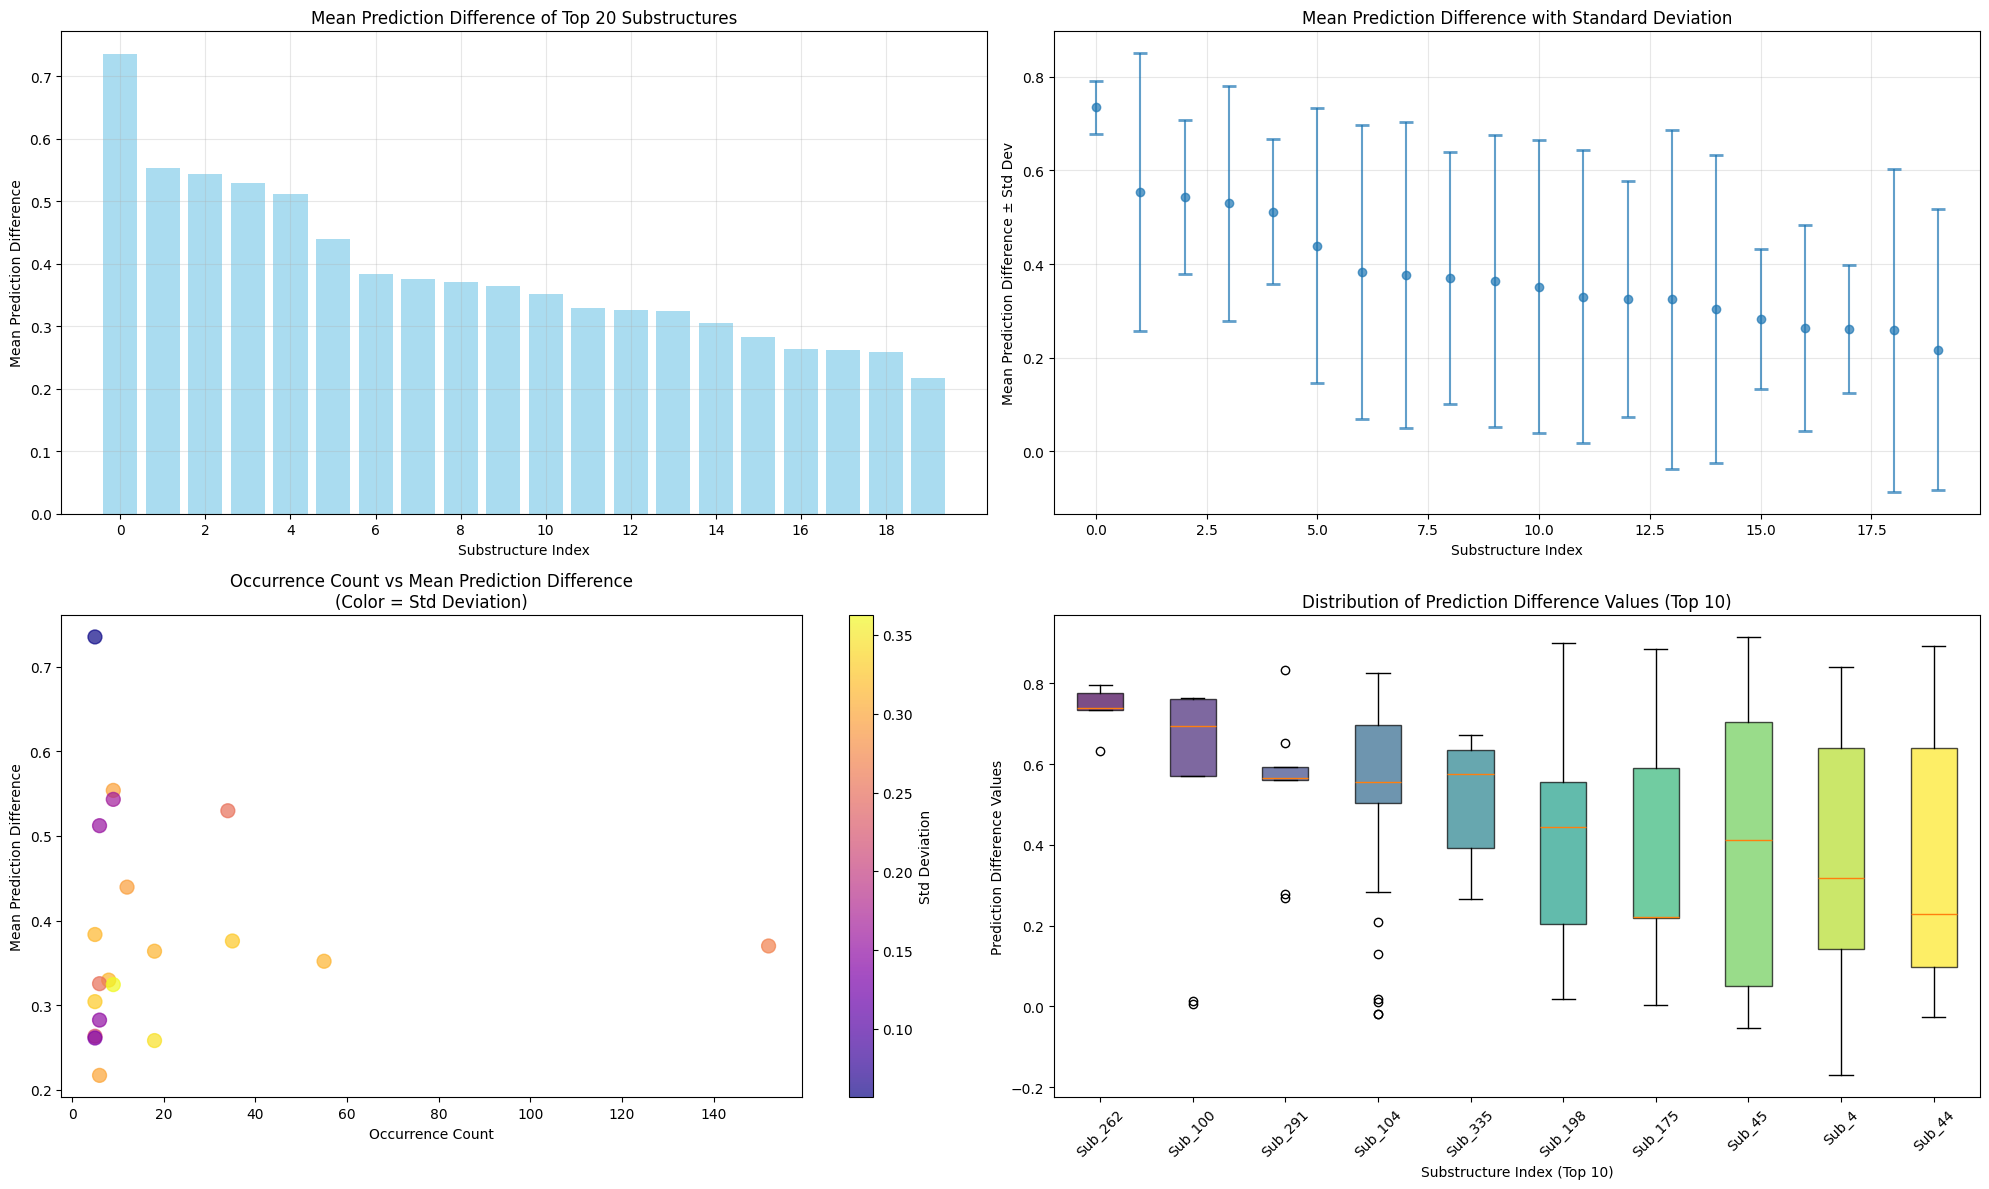

In [90]:
# Get top 20 substructures by mean Prediction Difference
top_20 = analysis_results[:20]

# Prepare data for plotting
substructure_names = [f"Sub_{result['group_id']}" for result in top_20]
mean_similarities = [result['mean_similarity'] for result in top_20]
counts = [result['count'] for result in top_20]
std_similarities = [result['std_similarity'] for result in top_20]

# Alternative visualization with box plots
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Bar chart of mean Prediction Difference
axes[0,0].bar(range(len(top_20)), mean_similarities, color='skyblue', alpha=0.7)
axes[0,0].set_xlabel('Substructure Index')
axes[0,0].set_ylabel('Mean Prediction Difference')
axes[0,0].set_title('Mean Prediction Difference of Top 20 Substructures')
axes[0,0].set_xticks(range(0, 20, 2))
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Scatter plot with error bars
axes[0,1].errorbar(range(len(top_20)), mean_similarities, yerr=std_similarities, 
                   fmt='o', capsize=5, capthick=2, alpha=0.7)
axes[0,1].set_xlabel('Substructure Index')
axes[0,1].set_ylabel('Mean Prediction Difference ± Std Dev')
axes[0,1].set_title('Mean Prediction Difference with Standard Deviation')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Count vs Mean Prediction Difference
scatter = axes[1,0].scatter(counts, mean_similarities, 
                           c=std_similarities, s=100, alpha=0.7, cmap='plasma')
axes[1,0].set_xlabel('Occurrence Count')
axes[1,0].set_ylabel('Mean Prediction Difference')
axes[1,0].set_title('Occurrence Count vs Mean Prediction Difference\n(Color = Std Deviation)')
plt.colorbar(scatter, ax=axes[1,0], label='Std Deviation')

# Plot 4: Box plot of top 10 substructures
top_10_data = [substructure_groups[result['group_id']]['similarities'] for result in top_20[:10]]
bp = axes[1,1].boxplot(top_10_data, patch_artist=True)
axes[1,1].set_xlabel('Substructure Index (Top 10)')
axes[1,1].set_ylabel('Prediction Difference Values')
axes[1,1].set_title('Distribution of Prediction Difference Values (Top 10)')
axes[1,1].set_xticklabels([f"Sub_{top_20[i]['group_id']}" for i in range(10)], rotation=45)

# Color the boxes
colors = plt.cm.viridis(np.linspace(0, 1, 10))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()
